In [1]:
import arviz as az
import pandas as pd
import json
import os

import numpy as np
import diffrax
import matplotlib.pyplot as plt
import matplotlib as mpl
import met_brewer as mb
import seaborn as sns
import jax
import sys

sys.path.append("../")
from utils import *
from plotting_helper_funcs import *

sys.path.append("../models/")
from MM_nonessential_all_diffrax import *

# tell jax to use 64bit floats
jax.config.update("jax_enable_x64", True)

plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True

Set up: Models, data, etc.

In [4]:
sampler = "Pathfinder"

plot_color = '#175449'

model = "MM_nonessential_all"
model_info_file = '../models/MM_nonessential_all.json'

data_dir = '../../../results/param_est/kinase_KO/std_dcr/'
save_dir_base = '../../../results/predictions/LKB1/'

save_dir = save_dir_base + model + '/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# load the model info
with open(model_info_file, 'r') as f:
    model_info = json.load(f)

state_names = list(model_info["init_conds"].keys())
ampkar_states = model_info['ampkar_states']
pampkar_states = model_info['pampkar_states']
y0 = list(model_info["init_conds"].values())

param_names = model_info["params"]


# get the indices of the states
ampkar_idxs = [state_names.index(item) for item in ampkar_states]
pampkar_idxs = [state_names.index(item) for item in pampkar_states]

# parameters for the metabolic model
metab_params_file = '../models/metabolism_params_Coccimiglio.json'
with open(metab_params_file, 'r') as file:
        metab_params = json.load(file)

basal_params = list(metab_params["metab_params_basal"].values())
stress_params = list(metab_params["metab_params_stress"].values()) # this is what we can modify to change the stimulus strength
k_gly_idx = list(metab_params["metab_params_basal"].keys()).index("kGly")
k_hydro_idx = list(metab_params["metab_params_basal"].keys()).index("kHydro")


# idata
idata_cyto = az.from_netcdf(data_dir + model + '_cyto_mcmc_samples_' + sampler + '.nc')

# load data to get simulation time
_, _, times = load_data('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz', 
                        to_seconds=True, constant_std=False)

rtol = 1e-6
atol = 1e-6
evnt_rtol = 1e-12
evnt_atol = 1e-12
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0
tmax_init = 1e3

ca_index = list(model_info["init_conds"].keys()).index("Ca")
total_AMPKAR = model_info["init_conds"]["AMPKAR"]

MM_non_all = eval(model + '(' + ','.join(str(elm) for elm in basal_params) \
            + ')')
rhs = dfrx.ODETerm(MM_non_all.prescribe_Ca_ATP_flux)

width= 1.5
height= 1.25

Write a function to run all simulations and return the results. It takes the desired 
stimuli as the inputs

In [5]:
# func to compute time to half max
# calculate time to half max of pAMPKAR_stressed/AMPKAR_stressed

def ramp_signal(times, start_level, end_level, ramp_duration, start_time=0, reverse=False):
    """
    Generate a ramp signal starting at a specified time, with an option to reverse the ramp.

    Parameters:
    times (array): Array of time points.
    start_level (float): The starting value of the ramp.
    end_level (float): The ending value of the ramp.
    ramp_duration (float): Duration of the ramp.
    start_time (float): The time at which the ramp starts.
    reverse (bool): If True, the ramp will go back down after reaching the end level.

    Returns:
    array: Array of the same length as times with the ramp signal.
    """
    slope = (end_level - start_level) / ramp_duration
    ramp_up = start_level + slope * (times - start_time)
    ramp_up = jax.numpy.where(times < start_time, start_level, ramp_up)
    ramp_up = jax.numpy.where(times > start_time + ramp_duration, end_level, ramp_up)

    if reverse:
        ramp_down = end_level - slope * (times - (start_time + ramp_duration))
        ramp_down = jax.numpy.where(times <= start_time + ramp_duration, end_level, ramp_down)
        ramp_down = jax.numpy.where(times > start_time + 2 * ramp_duration, start_level, ramp_down)
        return jax.numpy.where(times > start_time + ramp_duration, ramp_down, ramp_up)

    return ramp_up

def step_signal(times, step_time, start_level, end_level, reverse=False, reverse_time=None):
    """
    Generate a step signal that changes from start_level to end_level at a specified time,
    with an option to reverse back to the start_level at a later time.

    Parameters:
    times (array): Array of time points.
    step_time (float): The time at which the step occurs.
    start_level (float): The value before the step.
    end_level (float): The value after the step.
    reverse (bool): If True, the signal will reverse back to start_level.
    reverse_time (float): The time at which the signal reverses back to start_level.

    Returns:
    array: Array of the same length as times with the step signal.
    """
    signal = jax.numpy.where(times < step_time, start_level, end_level)
    if reverse and reverse_time is not None:
        signal = jax.numpy.where(times >= reverse_time, start_level, signal)
    return signal

def ramp_hold_signal(times, start_level, end_level, ramp_duration, hold_duration, start_time=0):
    """
    Generate a signal that ramps up, holds at a high level, and then ramps back down.

    Parameters:
    times (array): Array of time points.
    start_level (float): The starting value of the signal.
    end_level (float): The peak value of the signal.
    ramp_duration (float): Duration of the ramp up and ramp down.
    hold_duration (float): Duration to hold the signal at the peak value.
    start_time (float): The time at which the ramp starts.

    Returns:
    array: Array of the same length as times with the ramp-hold signal.
    """
    slope = (end_level - start_level) / ramp_duration
    ramp_up = start_level + slope * (times - start_time)
    ramp_up = jax.numpy.where(times < start_time, start_level, ramp_up)
    ramp_up = jax.numpy.where(times > start_time + ramp_duration, end_level, ramp_up)

    hold_start = start_time + ramp_duration
    hold_end = hold_start + hold_duration
    hold = jax.numpy.where((times >= hold_start) & (times <= hold_end), end_level, ramp_up)

    ramp_down = end_level - slope * (times - hold_end)
    ramp_down = jax.numpy.where(times <= hold_end, hold, ramp_down)
    ramp_down = jax.numpy.where(times > hold_end + ramp_duration, start_level, ramp_down)

    return ramp_down

def dynamic_stim(params, rhs, y0, times, Ca_func, kHydro_func, Ca_basal, kHydro_basal,
        tmax_init=1e3, rtol=1e-6, atol=1e-6, pcoeff=0.3, 
        icoeff=0.4, dcoeff=0.0, dt0=1e-10, solver = dfrx.Kvaerno5()):
    """ Function to solve the ODE with dynamic stimuli. The time-dependent RHS func expercts functions for the Ca2+ concentration and kHydro rate as the final two params in the params list (calcium first, then kHydro)."""
    
    # solver details
    stepsize_controller=dfrx.PIDController(rtol, atol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=dcoeff)
    t0 = 0.0
    t1 = times[-1]
    saveat=dfrx.SaveAt(ts=times)
    # max_steps=int(3)

    # first equilibrate the system with basal conditions
    ca_basal_func = lambda t: Ca_basal
    kHydro_basal_func = lambda t: kHydro_basal

    basal_params = list(params.copy())
    basal_params.append(ca_basal_func)
    basal_params.append(kHydro_basal_func)

    sol = dfrx.diffeqsolve(
        rhs, solver, 
        t0, tmax_init, dt0, 
        y0, 
        args=basal_params,
        stepsize_controller=stepsize_controller,
        # max_steps=max_steps,
        throw=True)
    
    # now apply the dynamic stimuli
    stim_params = list(params.copy())
    stim_params.append(Ca_func)
    stim_params.append(kHydro_func)

    # run the simulation
    sol_stressed = dfrx.diffeqsolve(
        rhs, solver, 
        t0, t1, dt0, 
        sol.ys, # use basal SS at IC
        args=stim_params, 
        saveat=saveat,
        stepsize_controller=stepsize_controller,
        # max_steps=max_steps,
        max_steps=None,
        throw=False)
    
    return jnp.squeeze(jnp.array(sol_stressed.ys))

def compute_pAMPK_activity(sol, param, pampk_idxs=np.array([10, 15, 16]), amp_pampk_idx=14):
    return sol[pampk_idxs, :].sum(axis=0)*param[12] + sol[amp_pampk_idx, :]*param[12]*param[24]

def plot_barplot(data_df, x_name, y_name, x_label, y_label, fig_width, fig_height, 
                 plot_color, invert_x=False, xticklabs=None,
                               rot_angle=0):
    fig, ax = get_sized_fig_ax(fig_width, fig_height)

    sns.barplot(data=data_df, x=x_name, y=y_name, 
            color=plot_color, ax=ax, edgecolor='black', alpha=0.75,
            errorbar='sd',err_kws={'color': 'black'})
    if invert_x:
        ax.invert_xaxis()
    
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)

    if xticklabs is not None:
        ax.set_xticklabels(xticklabs, fontsize=8, rotation=rot_angle)
    else:
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=rot_angle)
    
    ax.tick_params(axis='both', which='major', labelsize=8)


    return fig, ax

### Single step function of increase Ca2+ and ATP fluxes from baseline to something similar to the exercise model preds

We will start by simulating for one minute

#### Ca2+ flux
Base is zero in the exercise model
Maximum is near 5e4 uM/s

#### ATP Flux
Baseline ATP flux at IC is 1.23 mM/s
Values from exercise model are on the order of 2-2.25e3 uM/s with baselines near 5e2 uM/s

#### Levels to simulate
1. Baseline
2. 100 uM/s Ca2+ flux, 0.1 mM/s ATP flux
3. 500 uM/s Ca2+ flux, 0.5 mM/s ATP flux
4. 1000 uM/s Ca2+ flux, 1.0 mM/s ATP flux
5. 2000 uM/s Ca2+ flux, 2.0 mM/s ATP flux
6. 5000 uM/s Ca2+ flux, 5.0 mM/s ATP flux

#### Timing
begin with a 5 second (0.2 Hz) step function

In [6]:
nsamples=2
params = get_param_subsample(param_names, idata_cyto, nsamples) # two params for now, then draw a random subset

Now define time-dependent functions for the Ca2+ and ATP fluxes

In [7]:
# fig, ax = plt.subplots(1, 1, figsize=(5, 3))
# ax.plot(times, Ca_pulse(times), color=plot_color, lw=2)
Ca_end = 1
kHydro_end = 0.1

@jax.jit
def compute_pAMPK_act_AUC(ca_end, kHydro_end, param):

    Ca_stim_basal = lambda t: 0.1
    ATP_hydo_basal = lambda t: 0.0
    Ca_stim = lambda t: 0.1 + Ca_flux(t, ca_end)    
    kHydro_stim = lambda t: kHydro(t, kHydro_end)

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0, tsim, Ca_stim, kHydro_stim, 0.0, 0.0,
                   atol=1e-9, rtol=1e-9)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(sol, param)

    # compute the AUC
    pAMPK_activity_AUC = jnp.trapezoid(pAMPK_activity - pAMPK_activity[0], x=tsim)
    return pAMPK_activity_AUC, pAMPK_activity, sol

vmap_compute_pAMPK_act_AUC = jax.vmap(compute_pAMPK_act_AUC, in_axes=(None, None, 0))

### Now vary the duration of the step function

In [22]:
Ca_level = 0.1
ATP_flux_level = 2.0
tsim = np.linspace(0, 600, 4000)

Ca_force = lambda t, stim_length: 0.1 + step_signal(t, 5, 0.0, Ca_level, reverse=True,
                                            reverse_time=5+stim_length)
# baseline plus pulse

kHydro = lambda t, stim_length: step_signal(t, 5, 0.0, ATP_flux_level, reverse=True,
                                            reverse_time=5+stim_length)
# pulse only

stim_len = 10.0
LKB1_act_idx = 8

Ca_stim = lambda t: Ca_force(t, stim_len)    
kHydro_stim = lambda t: kHydro(t, stim_len)

@jax.jit
def compute_pAMPK_act_AUC_stim_len(LKB1_act_multiplier, param):

    # modify the LKB1 activity
    param = param.at[LKB1_act_idx].set(LKB1_act_multiplier*param[LKB1_act_idx])

    # test the dynamic stimulus function
    sol = dynamic_stim(param, rhs, y0, tsim, Ca_stim, kHydro_stim, 0.0, 0.0,
                   atol=1e-9, rtol=1e-9)
    
    # compute the pAMPK activity
    pAMPK_activity = compute_pAMPK_activity(sol, param)

    # compute the AUC
    pAMPK_activity_AUC = jnp.trapezoid(pAMPK_activity - pAMPK_activity[0], x=tsim)
    return pAMPK_activity_AUC, pAMPK_activity, sol

vmap_compute_pAMPK_act_AUC_stim_len = jax.vmap(compute_pAMPK_act_AUC_stim_len, in_axes=(None, 0))

mults = [0.0, 0.5, 1.0, 5.0, 10.0, 100.0]

auc_vals_stim_len = []
acts = []
sols = []
for mult in mults:
    # compute the AUC
    auc, pAMPK_act, sol = vmap_compute_pAMPK_act_AUC_stim_len(mult, params)
    
    auc_vals_stim_len.append([auc])
    acts.append([pAMPK_act])
    sols.append([sol])

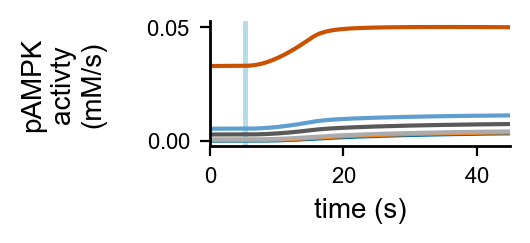

In [25]:
# pAMPK_act
fig, ax = get_sized_fig_ax(width, height/2)
xmax = 45
for i, mult in enumerate(mults):
    ax.plot(tsim, acts[i][0][0], label=str(mult))

ax.set_xlim(0, xmax)
ax.set_xticks([0, 20, 40])
ax.set_ylabel('pAMPK\nactivty\n'+r'(mM/s)', fontsize=10, labelpad=30, va='center')
ax.set_xlabel('time (s)', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.axvspan(5, 5.5, color='lightblue', alpha=0.9, zorder=0)
# fig.savefig(save_dir + 'Ca_30_pAMPK_act_transient.pdf', bbox_inches='tight', transparent=True)

In [ ]:
# generate a double exponential function that varies over time and increases from 0 to 1 with a specified timescale
